# **📊 2.3.2. Phân tích thống kê văn bản (Text EDA)**

In [1]:
from matplotlib.colors import LinearSegmentedColormap
from wordcloud import WordCloud
from scipy.stats import mannwhitneyu
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
import html
import re
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', None)

# Định nghĩa tên thư mục để lưu ảnh và file csv
output_dir = "eda_text"

## **Đọc dữ liệu và làm sạch HTML tag**

In [2]:
df = pd.read_csv("IMDB Dataset.csv")

def strip_html(text: str) -> str:
    text = str(text)
    text = html.unescape(text)
    text = re.sub(r'<\s*br\s*/?\s*>', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

df['text_clean'] = df['review'].apply(strip_html)
df.head()

,review,sentiment,text_clean
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side.",positive,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me. The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word. It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away. I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side."
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only ""has got all the polari"" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth th

## **🔹a) Phân phối độ dài văn bản và kiểm định Mann-Whitney U**

### **📏 Độ dài văn bản**
Độ dài văn bản là một đặc trưng quan trọng trong các bài toán xử lý ngôn ngữ tự nhiên. Trong phần thực nghiệm, độ dài văn bản được tính theo hai cách:

- **Độ dài ký tự (character length)**: tổng số ký tự trong chuỗi văn bản  
  $$ \text{char\_length} = \text{len(text)} $$

- **Độ dài từ (word length)**: số lượng từ sau khi tách theo khoảng trắng  
  $$ \text{word\_length} = \text{len(text.split())} $$

Việc phân tích phân phối độ dài theo từng nhãn lớp giúp xác định liệu các lớp có sự khác biệt đáng kể về mặt cấu trúc hay không (ví dụ: một lớp có xu hướng viết dài hơn lớp còn lại).

---

### **🔍 Kiểm định Mann-Whitney U**

Để kiểm tra sự khác biệt về độ dài giữa hai lớp, sử dụng **kiểm định Mann-Whitney U** – một kiểm định phi tham số dùng để so sánh hai mẫu độc lập.

Khác với kiểm định t-test, Mann-Whitney U:
- Không yêu cầu dữ liệu tuân theo phân phối chuẩn  
- So sánh **phân phối (distribution)** thay vì chỉ so sánh trung bình (mean)


#### **📌 Ý tưởng**
- Gộp tất cả giá trị của hai nhóm lại và **xếp hạng (ranking)**  
- Tính tổng hạng của từng nhóm  
- Nếu hai nhóm có phân phối giống nhau → tổng hạng sẽ gần nhau  
- Nếu khác nhau → tổng hạng lệch đáng kể  
 

#### **📐 Công thức**
Giả sử:
- Nhóm 1 có kích thước $n_1$
- Nhóm 2 có kích thước $n_2$
- $R_1$ là tổng thứ hạng của nhóm 1

Khi đó thống kê kiểm định:

$$
U_1 = n_1 n_2 + \frac{n_1 (n_1 + 1)}{2} - R_1
$$

Tương tự cho nhóm 2:

$$
U_2 = n_1 n_2 - U_1
$$

Giá trị U cuối cùng:

$$
U = \min(U_1, U_2)
$$



#### **📊 Giả thuyết kiểm định**

- **H0**: Hai nhóm có cùng phân phối (không có sự khác biệt về độ dài văn bản)  
- **H1**: Hai nhóm có phân phối khác nhau  

#### **📌 p-value trong kiểm định Mann-Whitney U**

Giá trị p-value được tính dựa trên thống kê U nhằm đánh giá xác suất xảy ra sự khác biệt quan sát được nếu giả thuyết H0 là đúng.

Cụ thể:
- Thống kê U được chuẩn hóa về phân phối chuẩn:
$$
Z = \frac{U - \mu_U}{\sigma_U}
$$

- Sau đó p-value được tính dựa trên phân phối chuẩn chuẩn hóa:
$$
p = 2 \cdot P(Z \ge |z|)
$$

Trong thực nghiệm, p-value được tính tự động bằng thư viện `scipy.stats.mannwhitneyu`.

#### **📌 Kết luận**

- Nếu **p-value < 0.05** → bác bỏ H0 → có sự khác biệt có ý nghĩa thống kê  
- Nếu **p-value ≥ 0.05** → chưa đủ bằng chứng để kết luận có sự khác biệt  


#### **⚠️ Lưu ý quan trọng**

- Mann-Whitney U **không kiểm định trực tiếp trung bình (mean)**  
- Nó kiểm tra sự khác biệt về **phân phối tổng thể** (median, shape, spread)  
- Trong code, kiểm định được áp dụng trên **word_length** (độ dài theo số từ)


=== Mann-Whitney U Test ===
Word count  → U=309189762,  p=4.0240e-02  : Khác biệt có ý nghĩa
Char count  → U=310754248,  p=2.7935e-01  : Không có ý nghĩa


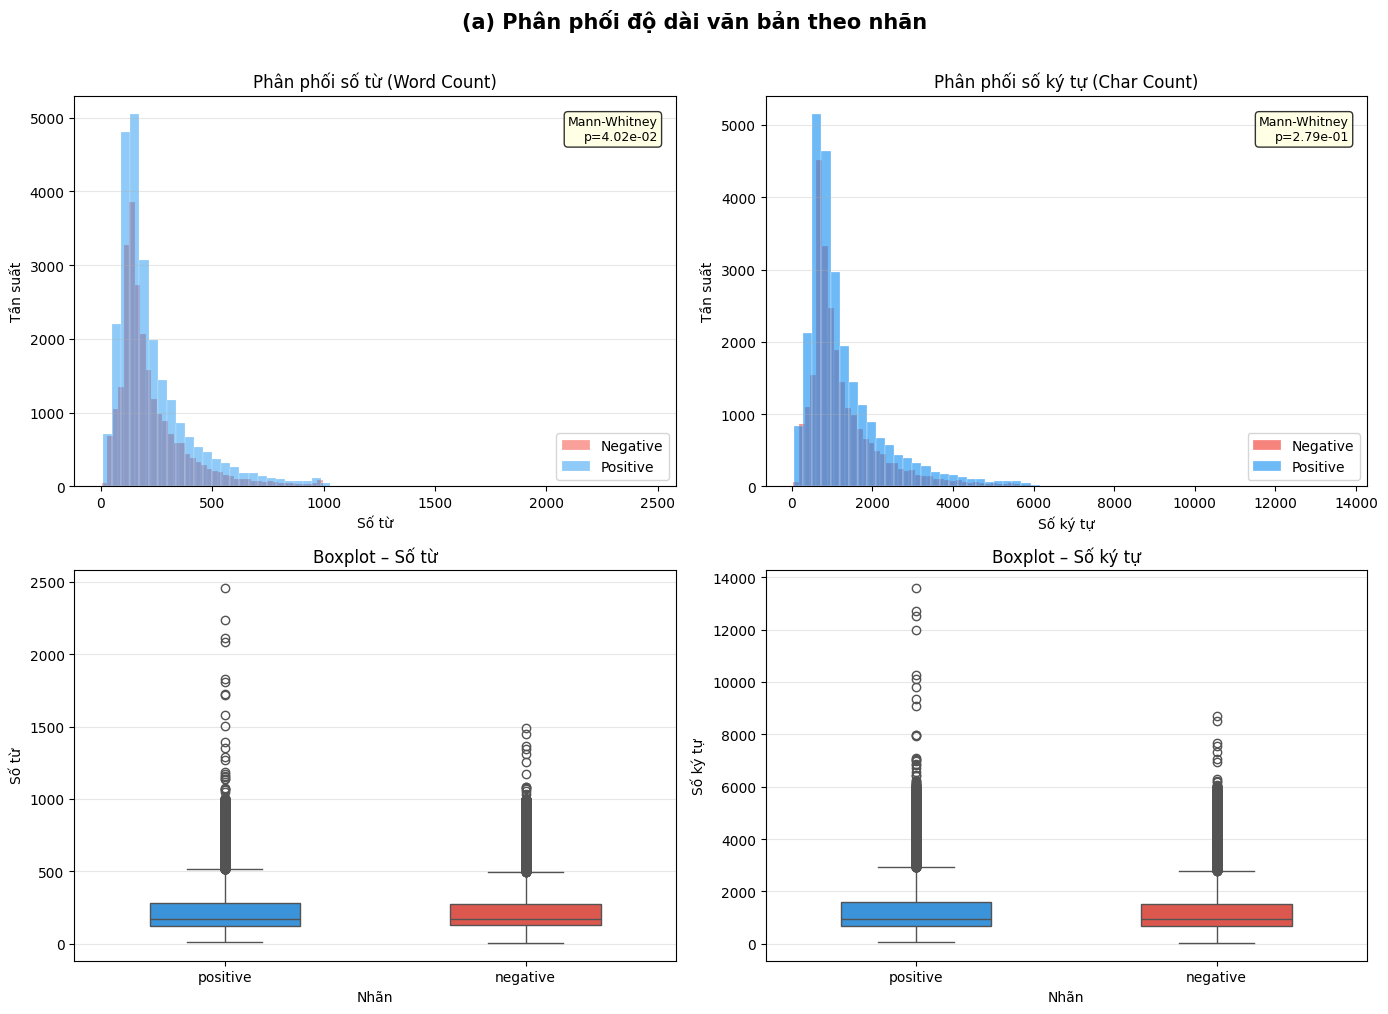

Đã lưu: eda_a_length_distribution.png


In [3]:
# a) Phân phối độ dài văn bản + Mann-Whitney U test
# ════════════════════════════════════════════════════════════════════════════
df['word_count'] = df['text_clean'].apply(lambda x: len(x.split()))
df['char_count'] = df['text_clean'].apply(len)

pos = df[df['sentiment'] == 'positive']
neg = df[df['sentiment'] == 'negative']

# ── Mann-Whitney U test ──────────────────────────────────────────────────
stat_w, p_w = mannwhitneyu(pos['word_count'], neg['word_count'], alternative='two-sided')
stat_c, p_c = mannwhitneyu(pos['char_count'], neg['char_count'], alternative='two-sided')

print("\n=== Mann-Whitney U Test ===")
print(f"Word count  → U={stat_w:.0f},  p={p_w:.4e}  {': Khác biệt có ý nghĩa' if p_w < 0.05 else ': Không có ý nghĩa'}")
print(f"Char count  → U={stat_c:.0f},  p={p_c:.4e}  {': Khác biệt có ý nghĩa' if p_c < 0.05 else ': Không có ý nghĩa'}")

# ── Thống kê mô tả ──────────────────────────────────────────────────────────────────
desc_stats = df.groupby('sentiment')[['word_count', 'char_count']].describe().round(1)
desc_stats_t = desc_stats.T
desc_stats_t.style.set_caption("Bảng so sánh thống kê độ dài văn bản (Positive vs Negative)")\
            .background_gradient(cmap='RdYlGn', axis=1)\
            .set_properties(**{'text-align': 'center', 'border': '1px solid gray'})
            
# ── Vẽ ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("(a) Phân phối độ dài văn bản theo nhãn", fontsize=15, fontweight='bold', y=1.01)

colors = {'positive': '#2196F3', 'negative': '#F44336'}
palette = [colors['positive'], colors['negative']]

# Histogram – word count
for label, grp in df.groupby('sentiment'):
    axes[0, 0].hist(grp['word_count'], bins=60, alpha=0.5,
                    label=label.capitalize(), color=colors[label], edgecolor='white', linewidth=0.3)
axes[0, 0].set_title('Phân phối số từ (Word Count)')
axes[0, 0].set_xlabel('Số từ'); axes[0, 0].set_ylabel('Tần suất')
axes[0, 0].legend(); axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].text(0.97, 0.95, f'Mann-Whitney\np={p_w:.2e}', transform=axes[0, 0].transAxes,
                ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# Histogram – char count
for label, grp in df.groupby('sentiment'):
    axes[0, 1].hist(grp['char_count'], bins=60, alpha=0.65,
                    label=label.capitalize(), color=colors[label], edgecolor='white', linewidth=0.3)
axes[0, 1].set_title('Phân phối số ký tự (Char Count)')
axes[0, 1].set_xlabel('Số ký tự'); axes[0, 1].set_ylabel('Tần suất')
axes[0, 1].legend(); axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].text(0.97, 0.95, f'Mann-Whitney\np={p_c:.2e}', transform=axes[0, 1].transAxes,
                ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# Boxplot – word count
sns.boxplot(data=df, x='sentiment', y='word_count', palette=palette,
            order=['positive', 'negative'], ax=axes[1, 0], width=0.5)
axes[1, 0].set_title('Boxplot – Số từ'); axes[1, 0].set_xlabel('Nhãn'); axes[1, 0].set_ylabel('Số từ')
axes[1, 0].grid(axis='y', alpha=0.3)

# Boxplot – char count
sns.boxplot(data=df, x='sentiment', y='char_count', palette=palette,
            order=['positive', 'negative'], ax=axes[1, 1], width=0.5)
axes[1, 1].set_title('Boxplot – Số ký tự'); axes[1, 1].set_xlabel('Nhãn'); axes[1, 1].set_ylabel('Số ký tự')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()

save_path = os.path.join(output_dir, "eda_a_length_distribution.png")
plt.savefig(save_path, dpi=150, bbox_inches='tight')

plt.show()
print("Đã lưu: eda_a_length_distribution.png")

### **🔍 Nhận xét**

- **Word count:** p = 0.0402 < 0.05 → có sự khác biệt có ý nghĩa giữa hai lớp.
- **Char count:** p = 0.279 > 0.05 → không có sự khác biệt đáng kể.

### **✅ Kết luận**
- Hai lớp khác nhau về **độ dài theo số từ** nhưng **không khác biệt về số ký tự**.

## **🔹 b) Word Cloud, Top từ phổ biến và Type-Token Ratio (TTR)**

### **🌥️ Word Cloud**
Word Cloud là phương pháp trực quan hóa giúp hiển thị các từ xuất hiện trong văn bản, trong đó kích thước của từ tỷ lệ với tần suất xuất hiện.

### **📊 Top-50 từ phổ biến**
Việc liệt kê các từ xuất hiện nhiều nhất (top-50) cung cấp cái nhìn chi tiết hơn về đặc trưng từ vựng của từng lớp. Qua đó có thể phát hiện:
- Các từ khóa đặc trưng cho từng nhãn
- Sự trùng lặp hoặc khác biệt giữa các lớp

### **📌 Type-Token Ratio (TTR)**

TTR được tính theo công thức:

$$
TTR = \frac{\text{số từ khác nhau (types)}}{\text{tổng số từ (tokens)}}
$$

- TTR cao: từ vựng đa dạng  
- TTR thấp: từ vựng lặp lại nhiều  

Chỉ số này giúp đánh giá mức độ phong phú ngôn ngữ trong từng lớp dữ liệu.


=== Type-Token Ratio (TTR) ===
Positive: 0.0313  (73445 types / 2,345,473 tokens)
Negative: 0.0316  (70633 types / 2,234,420 tokens)


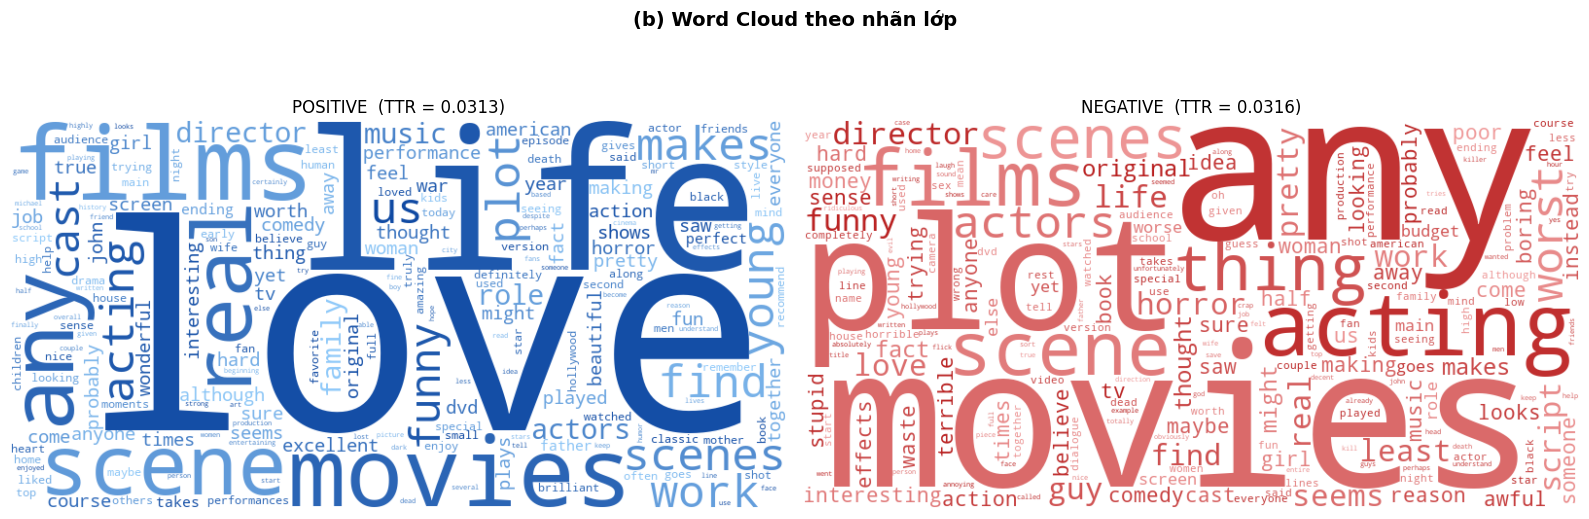

Đã lưu: eda_b_wordcloud.png

=== Top-50 từ phổ biến nhất ===
           word  freq_positive         word  freq_negative
0          love           8692          any           9125
1          life           8137       movies           8313
2         films           7601         plot           8214
3        movies           6996       acting           8087
4           any           5919        films           6154
5         scene           5177        scene           5791
6          real           5115        thing           5782
7        scenes           4881       scenes           5601
8        acting           4780       actors           4971
9          plot           4773        worst           4888
10        makes           4700     director           4812
11         work           4474         life           4780
12        young           4473        funny           4644
13         find           4467         love           4316
14           us           4340         real           

In [4]:
# b) Word Cloud + Top-50 từ phổ biến + TTR
# ════════════════════════════════════════════════════════════════════════════
STOPWORDS_EN = {
    'i','me','my','myself','we','our','ours','ourselves','you','your','yours',
    'yourself','yourselves','he','him','his','himself','she','her','hers',
    'herself','it','its','itself','they','them','their','theirs','themselves',
    'what','which','who','whom','this','that','these','those','am','is','are',
    'was','were','be','been','being','have','has','had','having','do','does',
    'did','doing','a','an','the','and','but','if','or','because','as','until',
    'while','of','at','by','for','with','about','against','between','into',
    'through','during','before','after','above','below','to','from','up',
    'down','in','out','on','off','over','under','again','further','then',
    'once','here','there','when','where','why','how','all','both','each',
    'few','more','most','other','some','such','no','nor','not','only','own',
    'same','so','than','too','very','s','t','can','will','just','don',
    'should','now','d','ll','m','o','re','ve','y','ain','aren','couldn',
    'didn','doesn','hadn','hasn','haven','isn','ma','mightn','mustn',
    'needn','shan','shouldn','wasn','weren','won','wouldn','br','film',
    'movie','one','like','even','would','also','get','much','make','time',
    'see','well','really','good','great','way','know','think','first',
    'watch','watching','people','character','characters','story','little',
    'never','made','say','could','go','back','show','many','part','look',
    'two','something','every','end','lot','still','play','found','best',
    'seem','though','since','always','nothing','last','actually','far',
    'give','new','however','ever','later','whole','another','long','bad',
    'comes','especially','around','throughout','three','without','put',
    'need','going','let','seen','right','came','either','old','big',
    'set','almost','world','better','quite','take','want','left','years',
    'rather','may','man','done','next','series','point','including',
    'must','things','works','enough','place','minutes','everything',
    'bit','got','matter','kind','different','anything','simply','day',
    'comes','came','u','ok','cant','gets','doesnt','didnt',
}

def tokenize(text: str) -> list:
    """Lowercase + chỉ giữ từ có ≥ 2 ký tự, bỏ stopwords."""
    tokens = re.findall(r'\b[a-z]{2,}\b', text.lower())
    return [t for t in tokens if t not in STOPWORDS_EN]


# Tách token theo nhãn
pos_tokens = pos['text_clean'].apply(tokenize).explode().dropna()
neg_tokens = neg['text_clean'].apply(tokenize).explode().dropna()

pos_freq = Counter(pos_tokens)
neg_freq = Counter(neg_tokens)

# ── Type-Token Ratio (TTR) ───────────────────────────────────────────────
def ttr(token_series):
    total = len(token_series)
    unique = token_series.nunique()
    return unique / total if total else 0

ttr_pos = ttr(pos_tokens)
ttr_neg = ttr(neg_tokens)
print(f"\n=== Type-Token Ratio (TTR) ===")
print(f"Positive: {ttr_pos:.4f}  ({pos_tokens.nunique()} types / {len(pos_tokens):,} tokens)")
print(f"Negative: {ttr_neg:.4f}  ({neg_tokens.nunique()} types / {len(neg_tokens):,} tokens)")

# ── Word Cloud ────────────────────────────────────────────────────────────
cmap_pos = LinearSegmentedColormap.from_list('pos', ['#90CAF9', '#0D47A1'])
cmap_neg = LinearSegmentedColormap.from_list('neg', ['#EF9A9A', '#B71C1C'])

wc_pos = WordCloud(width=800, height=400, background_color='white',
                   max_words=200, colormap=cmap_pos,
                   collocations=False).generate_from_frequencies(pos_freq)
wc_neg = WordCloud(width=800, height=400, background_color='white',
                   max_words=200, colormap=cmap_neg,
                   collocations=False).generate_from_frequencies(neg_freq)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("(b) Word Cloud theo nhãn lớp", fontsize=14, fontweight='bold')
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title(f'POSITIVE  (TTR = {ttr_pos:.4f})', fontsize=12)
axes[0].axis('off')
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title(f'NEGATIVE  (TTR = {ttr_neg:.4f})', fontsize=12)
axes[1].axis('off')
plt.tight_layout()

save_path = os.path.join(output_dir, "eda_b_wordcloud.png")
plt.savefig(save_path, dpi=150, bbox_inches='tight')

plt.show()
print("Đã lưu: eda_b_wordcloud.png")

# ── Bảng Top-50 từ phổ biến nhất ─────────────────────────────────────────
top50_pos = pd.DataFrame(pos_freq.most_common(50), columns=['word', 'freq_positive'])
top50_neg = pd.DataFrame(neg_freq.most_common(50), columns=['word', 'freq_negative'])
top50 = pd.concat([top50_pos, top50_neg], axis=1)
print("\n=== Top-50 từ phổ biến nhất ===")
print(top50.to_string(index=True))


csv_path = os.path.join(output_dir, "eda_b_top50_words.csv")
# Lưu file
top50.to_csv(csv_path, index=False)
print(f"Đã lưu bảng thống kê tại: {csv_path}")

### **🔍 Nhận xét**
- TTR của cả hai lớp đều **thấp (~3%)**  
- Lớp **negative cao hơn nhẹ** → từ vựng lớp negative đa dạng hơn một chút.
- Tuy nhiên, **chênh lệch rất nhỏ (~0.0003)** → **không đáng kể**.

### **✅ Kết luận**
- Không có sự khác biệt rõ ràng về độ phong phú từ vựng giữa hai lớp.

## **🔹 c) Phân phối Zipf**

### 📌 **Cụ thể**

Định luật Zipf là một quy luật thực nghiệm trong ngôn ngữ học, phát biểu rằng:

> Tần suất xuất hiện của một từ tỷ lệ nghịch với thứ hạng của nó trong danh sách các từ được sắp xếp theo tần suất giảm dần.

Cụ thể:
- Từ phổ biến nhất xuất hiện nhiều nhất  
- Từ đứng thứ hai có tần suất xấp xỉ bằng một nửa  
- Các từ tiếp theo giảm dần theo quy luật  

Điều này phản ánh đặc điểm tự nhiên của ngôn ngữ: một số ít từ xuất hiện rất thường xuyên, trong khi phần lớn từ xuất hiện rất hiếm.

---

### ⚙️ **Phương pháp**

Để kiểm tra dữ liệu có tuân theo định luật Zipf hay không, thực hiện các bước:

- Đếm tần suất xuất hiện của từng từ trong toàn bộ tập dữ liệu  
- Sắp xếp các từ theo tần suất giảm dần để xác định **thứ hạng (rank)**  
- Vẽ biểu đồ trên hệ trục log-log:
  - Trục x: log(rank)  
  - Trục y: log(frequency)  

---

### ✅ **Kết luận**

- Nếu biểu đồ log-log gần với một đường thẳng → dữ liệu **tuân theo định luật Zipf**  
- Nếu lệch nhiều → dữ liệu có thể:
  - Chưa được làm sạch (nhiều nhiễu, ký tự thừa)  
  - Bị mất tính tự nhiên (ví dụ: dữ liệu tổng hợp, không phải ngôn ngữ thật)  


[Zipf - All]
  Hệ số hồi quy (slope) = -1.6892
  Intercept             = 8.3559
  So với Zipf lý tưởng  : |slope - (-1)| = 0.6892 → Lệch đáng kể

[Zipf - Positive]
  Hệ số hồi quy (slope) = -1.5879
  Intercept             = 7.6697
  So với Zipf lý tưởng  : |slope - (-1)| = 0.5879 → Lệch đáng kể

[Zipf - Negative]
  Hệ số hồi quy (slope) = -1.5735
  Intercept             = 7.5671
  So với Zipf lý tưởng  : |slope - (-1)| = 0.5735 → Lệch đáng kể


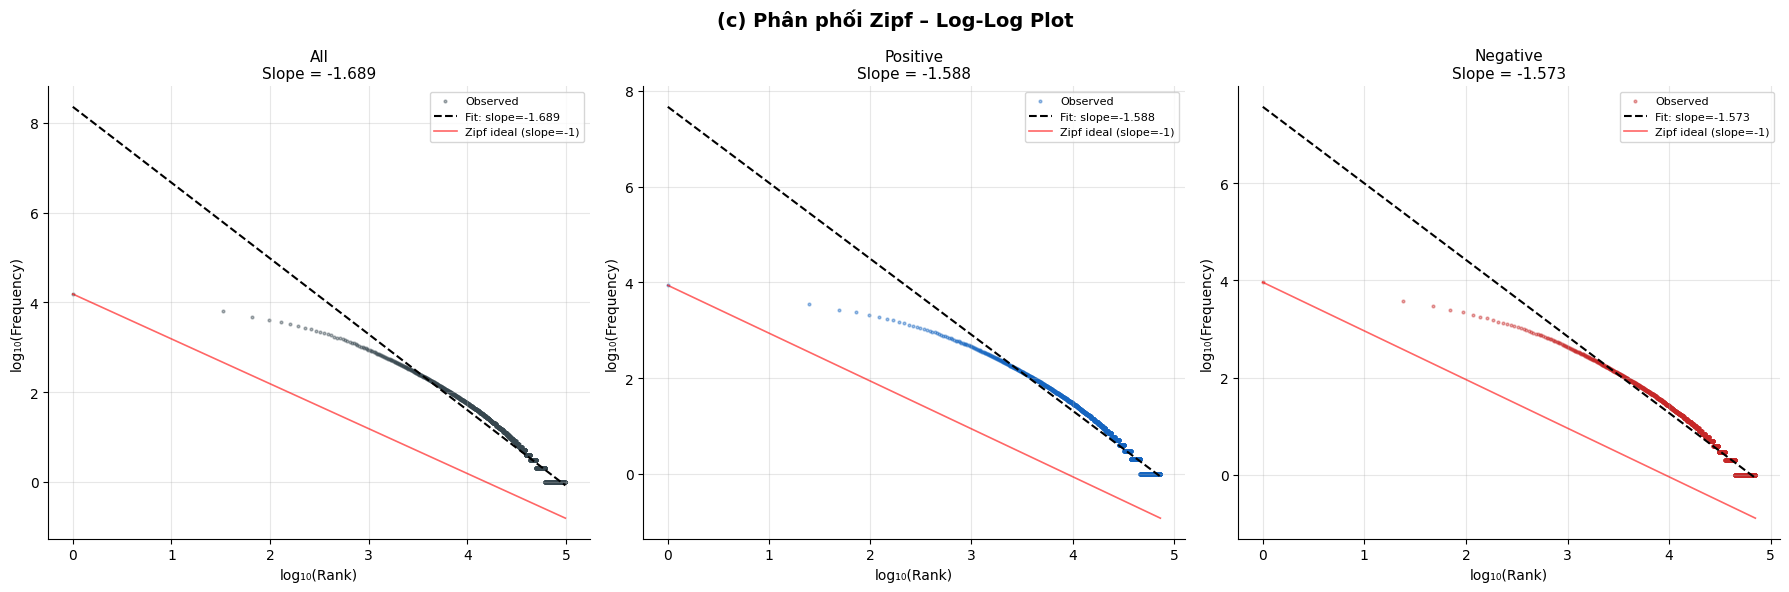


Đã lưu: eda_c_zipf.png


In [5]:
# c) Phân tích phân phối Zipf
# ════════════════════════════════════════════════════════════════════════════
def zipf_analysis(freq_counter, label, color):
    """Trả về ranks, freqs, và hệ số hồi quy log-log."""
    most_common = freq_counter.most_common()
    ranks  = np.arange(1, len(most_common) + 1)
    freqs  = np.array([f for _, f in most_common])
    log_r  = np.log10(ranks)
    log_f  = np.log10(freqs)
    # Hồi quy tuyến tính trên log-log
    coef   = np.polyfit(log_r, log_f, 1)
    return ranks, freqs, coef, log_r, log_f

# Toàn bộ corpus
all_tokens = pd.concat([pos_tokens, neg_tokens])
all_freq   = Counter(all_tokens)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("(c) Phân phối Zipf – Log-Log Plot", fontsize=14, fontweight='bold')

datasets = [
    (all_freq,  'All', '#37474F'),
    (pos_freq,  'Positive', '#1565C0'),
    (neg_freq,  'Negative', '#C62828'),
]

for ax, (freq, label, color) in zip(axes, datasets):
    ranks, freqs, coef, log_r, log_f = zipf_analysis(freq, label, color)

    # Scatter (subsample để nhanh hơn)
    step = max(1, len(ranks) // 3000)
    ax.scatter(np.log10(ranks[::step]), np.log10(freqs[::step]),
               s=4, alpha=0.4, color=color, label='Observed')

    # Đường hồi quy
    fit_line = np.polyval(coef, log_r)
    ax.plot(log_r, fit_line, 'k--', linewidth=1.5,
            label=f'Fit: slope={coef[0]:.3f}')

    # Đường Zipf lý tưởng (slope = -1)
    ideal = -1 * log_r + log_f[0]
    ax.plot(log_r, ideal, 'r-', linewidth=1.2, alpha=0.6, label='Zipf ideal (slope=-1)')

    ax.set_title(f'{label}\nSlope = {coef[0]:.3f}', fontsize=11)
    ax.set_xlabel('log₁₀(Rank)'); ax.set_ylabel('log₁₀(Frequency)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

    print(f"\n[Zipf - {label}]")
    print(f"  Hệ số hồi quy (slope) = {coef[0]:.4f}")
    print(f"  Intercept             = {coef[1]:.4f}")
    ideal_diff = abs(coef[0] - (-1))
    verdict = "Tuân theo tốt" if ideal_diff < 0.15 else ("Tuân theo tương đối" if ideal_diff < 0.3 else "Lệch đáng kể")
    print(f"  So với Zipf lý tưởng  : |slope - (-1)| = {ideal_diff:.4f} → {verdict}")

plt.tight_layout()
save_path = os.path.join(output_dir, "eda_c_zipf.png")
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print("\nĐã lưu: eda_c_zipf.png")

### **🔍 Nhận xét**
- Cả ba tập (All, Positive, Negative) đều có **slope ≈ -1.57 → -1.69**, gần với lý thuyết Zipf (-1).
- Tuy nhiên, **độ lệch khá lớn (~0.57 – 0.69)** → không tuân theo Zipf hoàn hảo.
- Phân phối vẫn giữ dạng **giảm tuyến tính trên log-log** → phù hợp đặc trưng ngôn ngữ tự nhiên.

### 🔍 So sánh
- **All lệch nhiều nhất** → dữ liệu tổng hợp đa dạng hơn.
- **Positive và Negative gần nhau** → không khác biệt rõ về cấu trúc từ vựng.

### ✅ Kết luận
- Dữ liệu **có xu hướng tuân theo Zipf**, nhưng **không hoàn hảo** do nhiễu và preprocessing.

## **Tổng kết**

In [6]:
# Tổng kết
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("TỔNG KẾT Text EDA (2.3.2)")
print("="*60)
print(f"{'Metric':<35} {'Positive':>12} {'Negative':>12}")
print("-"*60)
print(f"{'Số mẫu':<35} {len(pos):>12,} {len(neg):>12,}")
print(f"{'Trung bình số từ':<35} {pos['word_count'].mean():>12.1f} {neg['word_count'].mean():>12.1f}")
print(f"{'Trung bình số ký tự':<35} {pos['char_count'].mean():>12.1f} {neg['char_count'].mean():>12.1f}")
print(f"{'Tổng số token':<35} {len(pos_tokens):>12,} {len(neg_tokens):>12,}")
print(f"{'Số từ vựng duy nhất (types)':<35} {pos_tokens.nunique():>12,} {neg_tokens.nunique():>12,}")
print(f"{'TTR':<35} {ttr_pos:>12.4f} {ttr_neg:>12.4f}")
print(f"{'Mann-Whitney p (word_count)':<35} {p_w:>12.4e}")
print(f"{'Mann-Whitney p (char_count)':<35} {p_c:>12.4e}")
print("="*60)
print("\nFiles đã lưu:")

print("  - eda_a_length_distribution.png")
print("  - eda_b_wordcloud.png")
print("  - eda_b_top20_bar.png")
print("  - eda_b_top50_words.csv")
print("  - eda_c_zipf.png")


TỔNG KẾT Text EDA (2.3.2)
Metric                                  Positive     Negative
------------------------------------------------------------
Số mẫu                                    25,000       25,000
Trung bình số từ                           230.6        227.1
Trung bình số ký tự                       1302.9       1270.9
Tổng số token                          2,345,473    2,234,420
Số từ vựng duy nhất (types)               73,445       70,633
TTR                                       0.0313       0.0316
Mann-Whitney p (word_count)           4.0240e-02
Mann-Whitney p (char_count)           2.7935e-01

Files đã lưu:
  - eda_a_length_distribution.png
  - eda_b_wordcloud.png
  - eda_b_top20_bar.png
  - eda_b_top50_words.csv
  - eda_c_zipf.png
